In [1]:
import os
from typing import Sequence

import torch
import pandas as pd
from tqdm import tqdm
import warnings
from scipy.stats import wilcoxon

from sample_and_train_utilities import FlexibleCNN3D, LinearRegression
from inference_utilities import inference_complete, volumetric_map, visualize_volumetric_map, metrics, analyse_metrics, random_metrics
warnings.simplefilter('ignore')

/Users/askarabdullaev/Desktop/JKU COURSES/Practice/inference_utilities.py:753: SyntaxWarning: invalid escape sequence '\A'
  dcc_ax.set_xlabel('DCC Threshold ($\AA$)')


This notebook follows the cross_validation.ipynb notebook.

By now, the file structure should look like:

```text
./
|
|- all_scpdb_entries.txt
|- excluded_scpdb_entries.txt
|- original_split.txt
|
|- failed_downloads.csv
|- failed_web_pages.csv
|- failed_parsing.csv
|
|- Data
    |
    |- scPDB
        |- 1a2b_1
            |- protein.mol2
            |- site.mol2
            |- ...(other possible files from scPDB)
        |- ...(all scPDB entries)
    |
    |- SCOPe
        |- 2_08.csv
        |- ...(possibly other SCOPe versions)
    |
    |- Pages
        |- 1a2b_1.txt
        |- ...(all the source codes of scPDB web pages)
    |
    |- Folds
        |- 1.csv
        |- ...(other folds)
        |- test.csv
    |
    |- Atoms
        |- 1a2b_1.csv
        |- ...(csvs with atom coords and props)
    |
    |- Voxels
        |- 1
            |- 1a2b_1
                |- atoms_grid.npy
                |- occupancy.npy
                |- site_center.npy
            |- ... (other voxelized entries with voxel size 1)
        |
        |- 2
            |- 1a2b_1
                |- atoms_grid.npy
                |- occupancy.npy
                |- site_center.npy
            |- ... (other voxelized entries with voxel size 2)
    |
    |- CV
        |- analysis (folder with aggregated CSVs)
        |- pilot (folder for hyperparameter search)
            |- bs_128_do_0_cs_1
                |- train_loss.txt
                |- test_loss.txt
                |- true_labels.npy
                |- predictions.npy
            |- ... (other hyperparameter combinations)
        |
        |- vs_1_cnn
            |- params.csv (parameters of the run)   
            |- 0
                |- train_loss.txt
                |- test_loss.txt
                |- true_labels.npy
                |- predictions.npy
            |- ... (other folds)
        |
        |- ... (other models)
```

By the end of this notebook, the file structure will look like:

```text
./
|
|- all_scpdb_entries.txt
|- excluded_scpdb_entries.txt
|- original_split.txt
|
|- failed_downloads.csv
|- failed_web_pages.csv
|- failed_parsing.csv
|
|- Data
    |
    |- scPDB
        |- 1a2b_1
            |- protein.mol2
            |- site.mol2
            |- ...(other possible files from scPDB)
        |- ...(all scPDB entries)
    |
    |- SCOPe
        |- 2_08.csv
        |- ...(possibly other SCOPe versions)
    |
    |- Pages
        |- 1a2b_1.txt
        |- ...(all the source codes of scPDB web pages)
    |
    |- Folds
        |- 1.csv
        |- ...(other folds)
        |- test.csv
    |
    |- Atoms
        |- 1a2b_1.csv
        |- ...(csvs with atom coords and props)
    |
    |- Voxels
        |- 1
            |- 1a2b_1
                |- atoms_grid.npy
                |- occupancy.npy
                |- site_center.npy
            |- ... (other voxelized entries with voxel size 1)
        |
        |- 2
            |- 1a2b_1
                |- atoms_grid.npy
                |- occupancy.npy
                |- site_center.npy
            |- ... (other voxelized entries with voxel size 2)
    |
    |- CV
        |- analysis (folder with aggregated CSVs)
        |- pilot (folder for hyperparameter search)
            |- bs_128_do_0_cs_1
                |- train_loss.txt
                |- test_loss.txt
                |- true_labels.npy
                |- predictions.npy
            |- ... (other hyperparameter combinations)
        |
        |- vs_1_cnn
            |- params.csv (parameters of the run)   
            |- 0
                |- train_loss.txt
                |- test_loss.txt
                |- true_labels.npy
                |- predictions.npy
            |- ... (other folds)
        |
        |- ... (other models)
    |
    |- Inference (folder with subgrid scores)
        |- cnn
            |- 1a4z_4.npy
            |- (...other entries from the test set)
        |
        |- linear
            |- 1a4z_4.npy
            |- (...other entries from the test set)
    |
    |- final_metrics.csv
```

In [2]:
# Default dirs and paths

SCPDB_DIR = 'Data/scPDB'
SCOPE_DIR = 'Data/SCOPe'
SCOPE_VERSION = '2.08'
PAGES_DIR = 'Data/Pages'
FOLDS_DIR = 'Data/Folds'
ATOMS_DIR = 'Data/Atoms'
VOXELS_DIR = 'Data/Voxels'
MAIN_CSV = 'Data/database.csv'
CV_LOGS = 'Data/CV'
PILOT_DIR = 'Data/CV/pilot'
MODEL_DIR = '.'
CV_ANALYSIS = 'Data/CV/analysis'
INFERENCE_DIR = 'Data/Inference'  # Folder for subgrid scores
FINAL_METRICS = 'Data/final_metrics.csv'  # Path to the CSV of final domain-specific matrics

# Get Test Set

It is assumed that there is a file test.csv in FOLDS_DIR

In [3]:
test_entries = pd.read_csv(os.path.join(FOLDS_DIR, 'test.csv'))
test_entries = test_entries['Main'].to_list()
print(f'There are {len(test_entries)} scPDB Ids in the test set')

There are 1172 scPDB Ids in the test set


# Load Models

It is assumed that CNN and linear models are already saved in the <MODEL_DIR> and are called 'final_cnn.pt' and 'final_linear.pt'

In [4]:
cnn = torch.load(os.path.join(MODEL_DIR, 'final_cnn.pt'), weights_only=False)
print(f'3D CNN Model is loaded:\n{cnn}')

linear = torch.load(os.path.join(MODEL_DIR, 'final_linear.pt'), weights_only=False)
print(f'\nLinear Model is loaded:\n{linear}')

3D CNN Model is loaded:
FlexibleCNN3D(
  (model): Sequential(
    (0): Conv3d(8, 32, kernel_size=(8, 8, 8), stride=(1, 1, 1), padding=same)
    (1): ELU(alpha=1.0)
    (2): Conv3d(32, 48, kernel_size=(4, 4, 4), stride=(1, 1, 1), padding=same)
    (3): ELU(alpha=1.0)
    (4): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Dropout3d(p=0, inplace=False)
    (6): Conv3d(48, 64, kernel_size=(4, 4, 4), stride=(1, 1, 1), padding=same)
    (7): ELU(alpha=1.0)
    (8): Conv3d(64, 80, kernel_size=(4, 4, 4), stride=(1, 1, 1), padding=same)
    (9): ELU(alpha=1.0)
    (10): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout3d(p=0, inplace=False)
    (12): Flatten(start_dim=1, end_dim=-1)
    (13): Linear(in_features=5120, out_features=128, bias=True)
    (14): ELU(alpha=1.0)
    (15): Dropout(p=0, inplace=False)
    (16): Linear(in_features=128, out_features=1, bias=True)
  )
)

Linear Model is loaded:
LinearRegression(

# Inference

In the cell below, the models are used to get the scores for every subgrid from 1/2 of the proteins in the test set.

    IMPORTANT: the process might take around 16 hours

In [5]:
rerun = False

if rerun:

    inference_complete(model=linear,
                    scpdb_ids=test_entries[:len(test_entries) // 2] + ['2z08_1'],
                    voxel_size=1,
                    batch_size=64,
                    voxels_dir=VOXELS_DIR,
                    inference_dir=os.path.join(INFERENCE_DIR, 'linear'),
                    exist_ok=True,
                    device='cpu')

    inference_complete(model=cnn,
                    scpdb_ids=test_entries[:len(test_entries) // 2] + ['2z08_1'],
                    voxel_size=1,
                    batch_size=64,
                    voxels_dir=VOXELS_DIR,
                    inference_dir=os.path.join(INFERENCE_DIR, 'cnn'),
                    exist_ok=True,
                    device='cpu')

Here I show an example of how the scores grid looks like.

In [6]:
# v_map = volumetric_map(scpdb_id='2z08_1',
#                        radius=2,
#                        mode='mean',
#                        inference_dir=os.path.join(INFERENCE_DIR, 'cnn'))

# visualize_volumetric_map(scpdb_id='2z08_1',
#                          show_binding_site=True,
#                          threshold=0.5,
#                          radius=4,
#                          mode='mean',
#                          database_path=MAIN_CSV,
#                          voxels_dir=VOXELS_DIR,
#                          inference_dir=os.path.join(INFERENCE_DIR, 'cnn'),
#                          dpi=300,
#                          title=True,
#                          zoom=0,
#                          save=None)

# Domain-Specific Metrics (DCC + DVO)

Domain specific metrics
- DCC (Distance from Center to Center)
- DVO (Discretized Volumetric Overlap)

Following the DeepSite logic, I will also test several thresholds and choose the best one for my final metrics.

Note: linear model produce too many False Positives, which ruins HDBSCAN clustering. Thus, linear model will only be tested with thresholds >= 0.5

    IMPORTANT: the cell below might take around 24 hours

In [12]:
rerun = False

if rerun:
    metrics_df = []
    thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]

    with tqdm(total=3 * len(thresholds) * len(test_entries) // 2, desc='Computing metrics...') as pbar:

        for scpdb_id in tqdm(test_entries[:len(test_entries) // 2]):

            for t in thresholds:

                cnn_dcc, cnn_dvo, cnn_pos_density = metrics(scpdb_id, inference_dir=os.path.join(INFERENCE_DIR, 'cnn'), threshold=t, radius=4)
                pbar.update(1)
                lin_dcc, lin_dvo, _ = metrics(scpdb_id, inference_dir=os.path.join(INFERENCE_DIR, 'linear'), threshold=t, radius=4)
                pbar.update(1)
                rand_dcc, rand_dvo = random_metrics(scpdb_id, inference_dir=os.path.join(INFERENCE_DIR, 'cnn'), threshold=1-cnn_pos_density, seed=1234)
                pbar.update(1)

                metrics_df.extend([
                    [scpdb_id, 'cnn', t, cnn_dcc, cnn_dvo],
                    [scpdb_id, 'linear', t, lin_dcc, lin_dvo],
                    [scpdb_id, 'random', t, rand_dcc, rand_dvo]
                ])

    metrics_df = pd.DataFrame(metrics_df, columns=['scPDB ID', 'Model', 'Threshold', 'DCC', 'DVO'])
    metrics_df.to_csv(FINAL_METRICS, sep='\t', index=False)

### Analyse Metrics:

- plot DCC thresholds for both models and a random baseline
- plot DVO distirbution for both boxplots and a random baseline

Theshold = 0.5


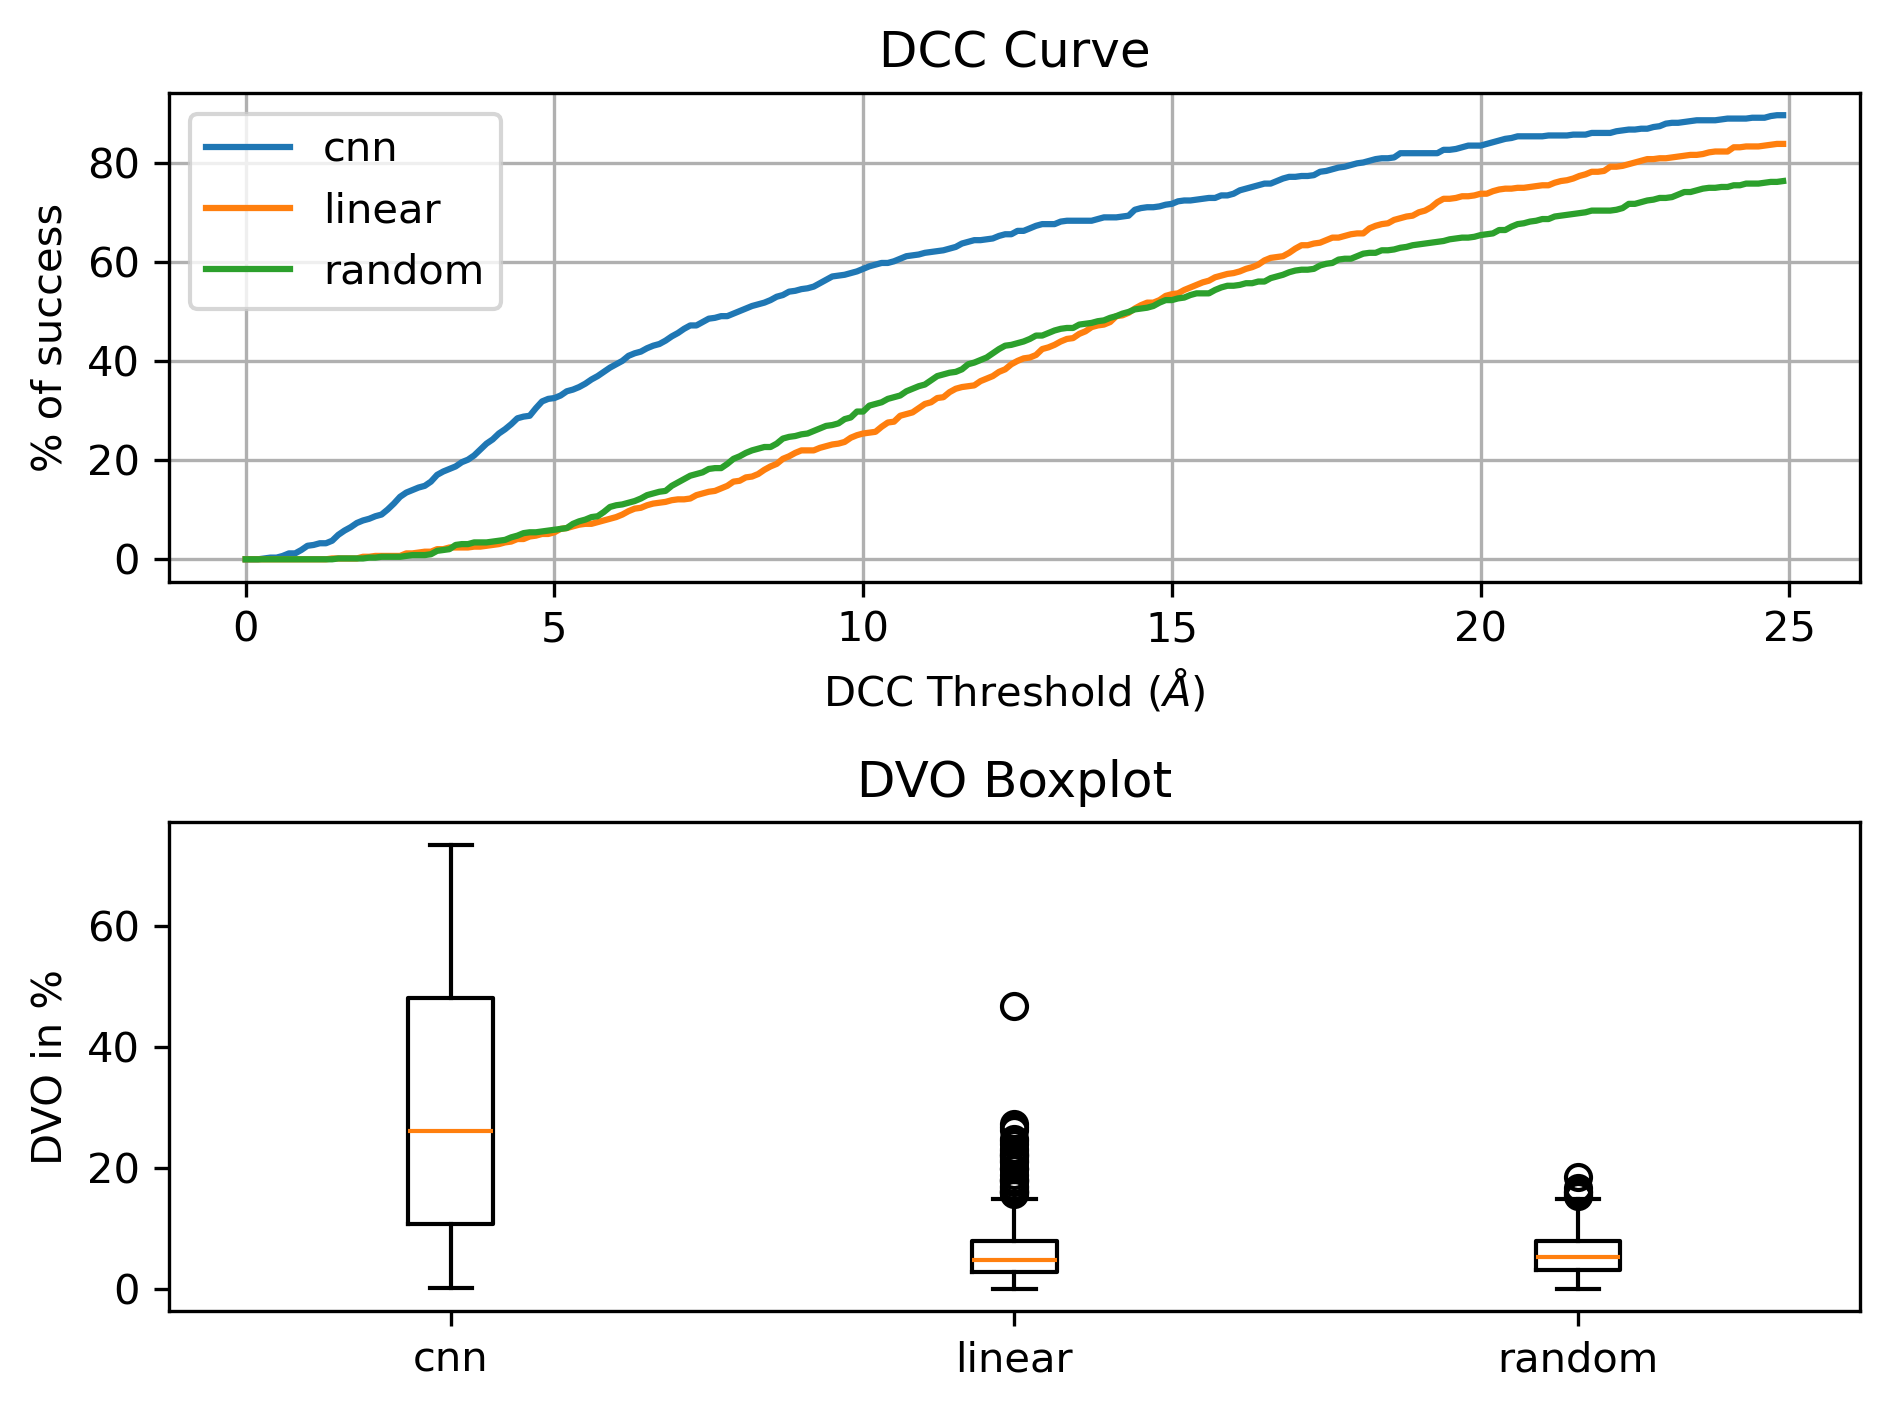

Theshold = 0.6


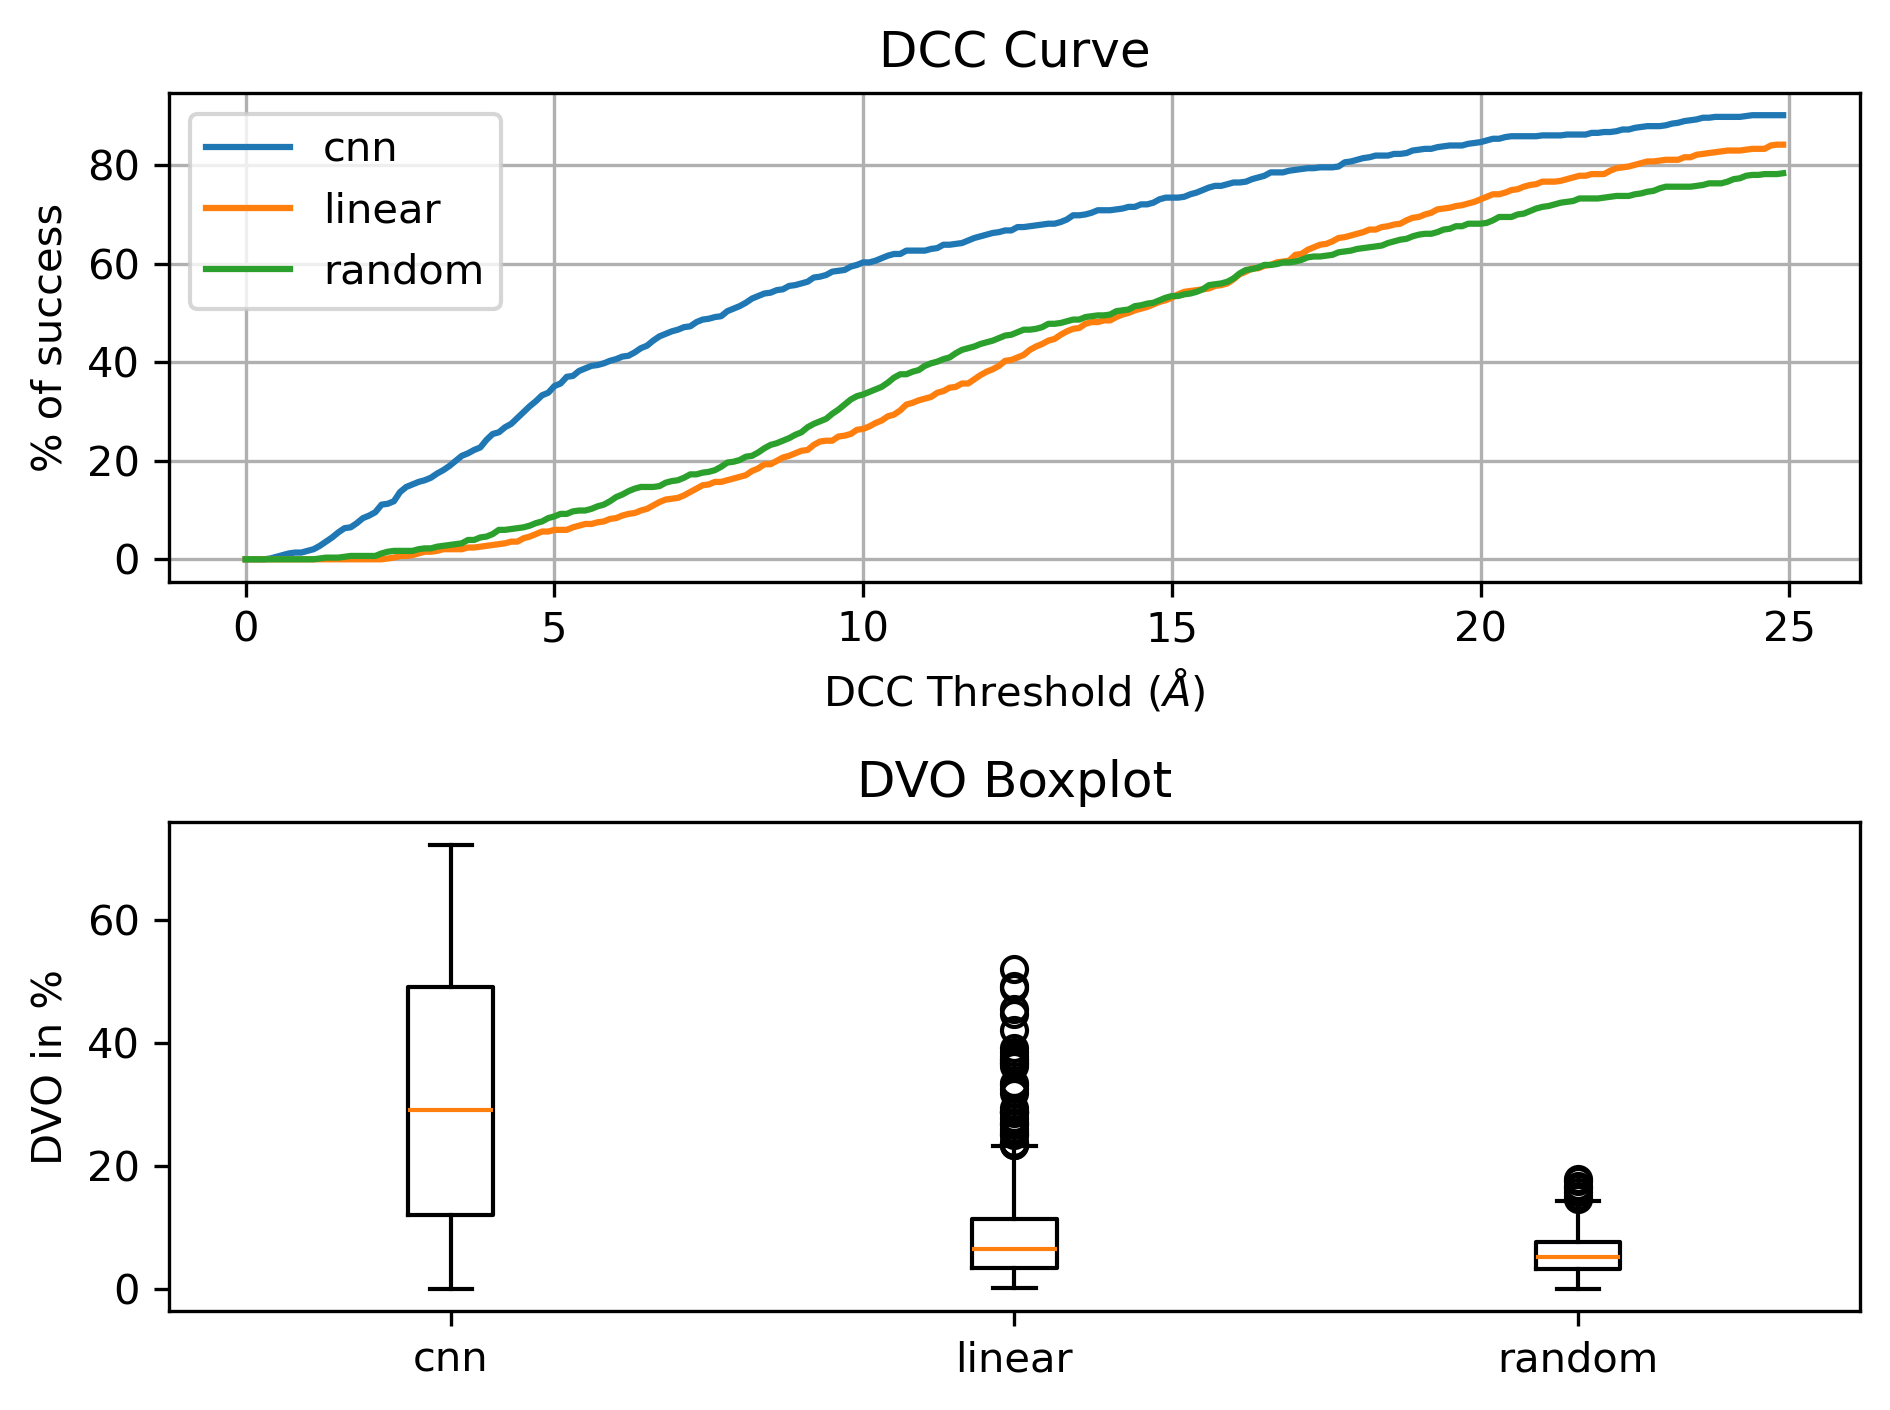

Theshold = 0.7


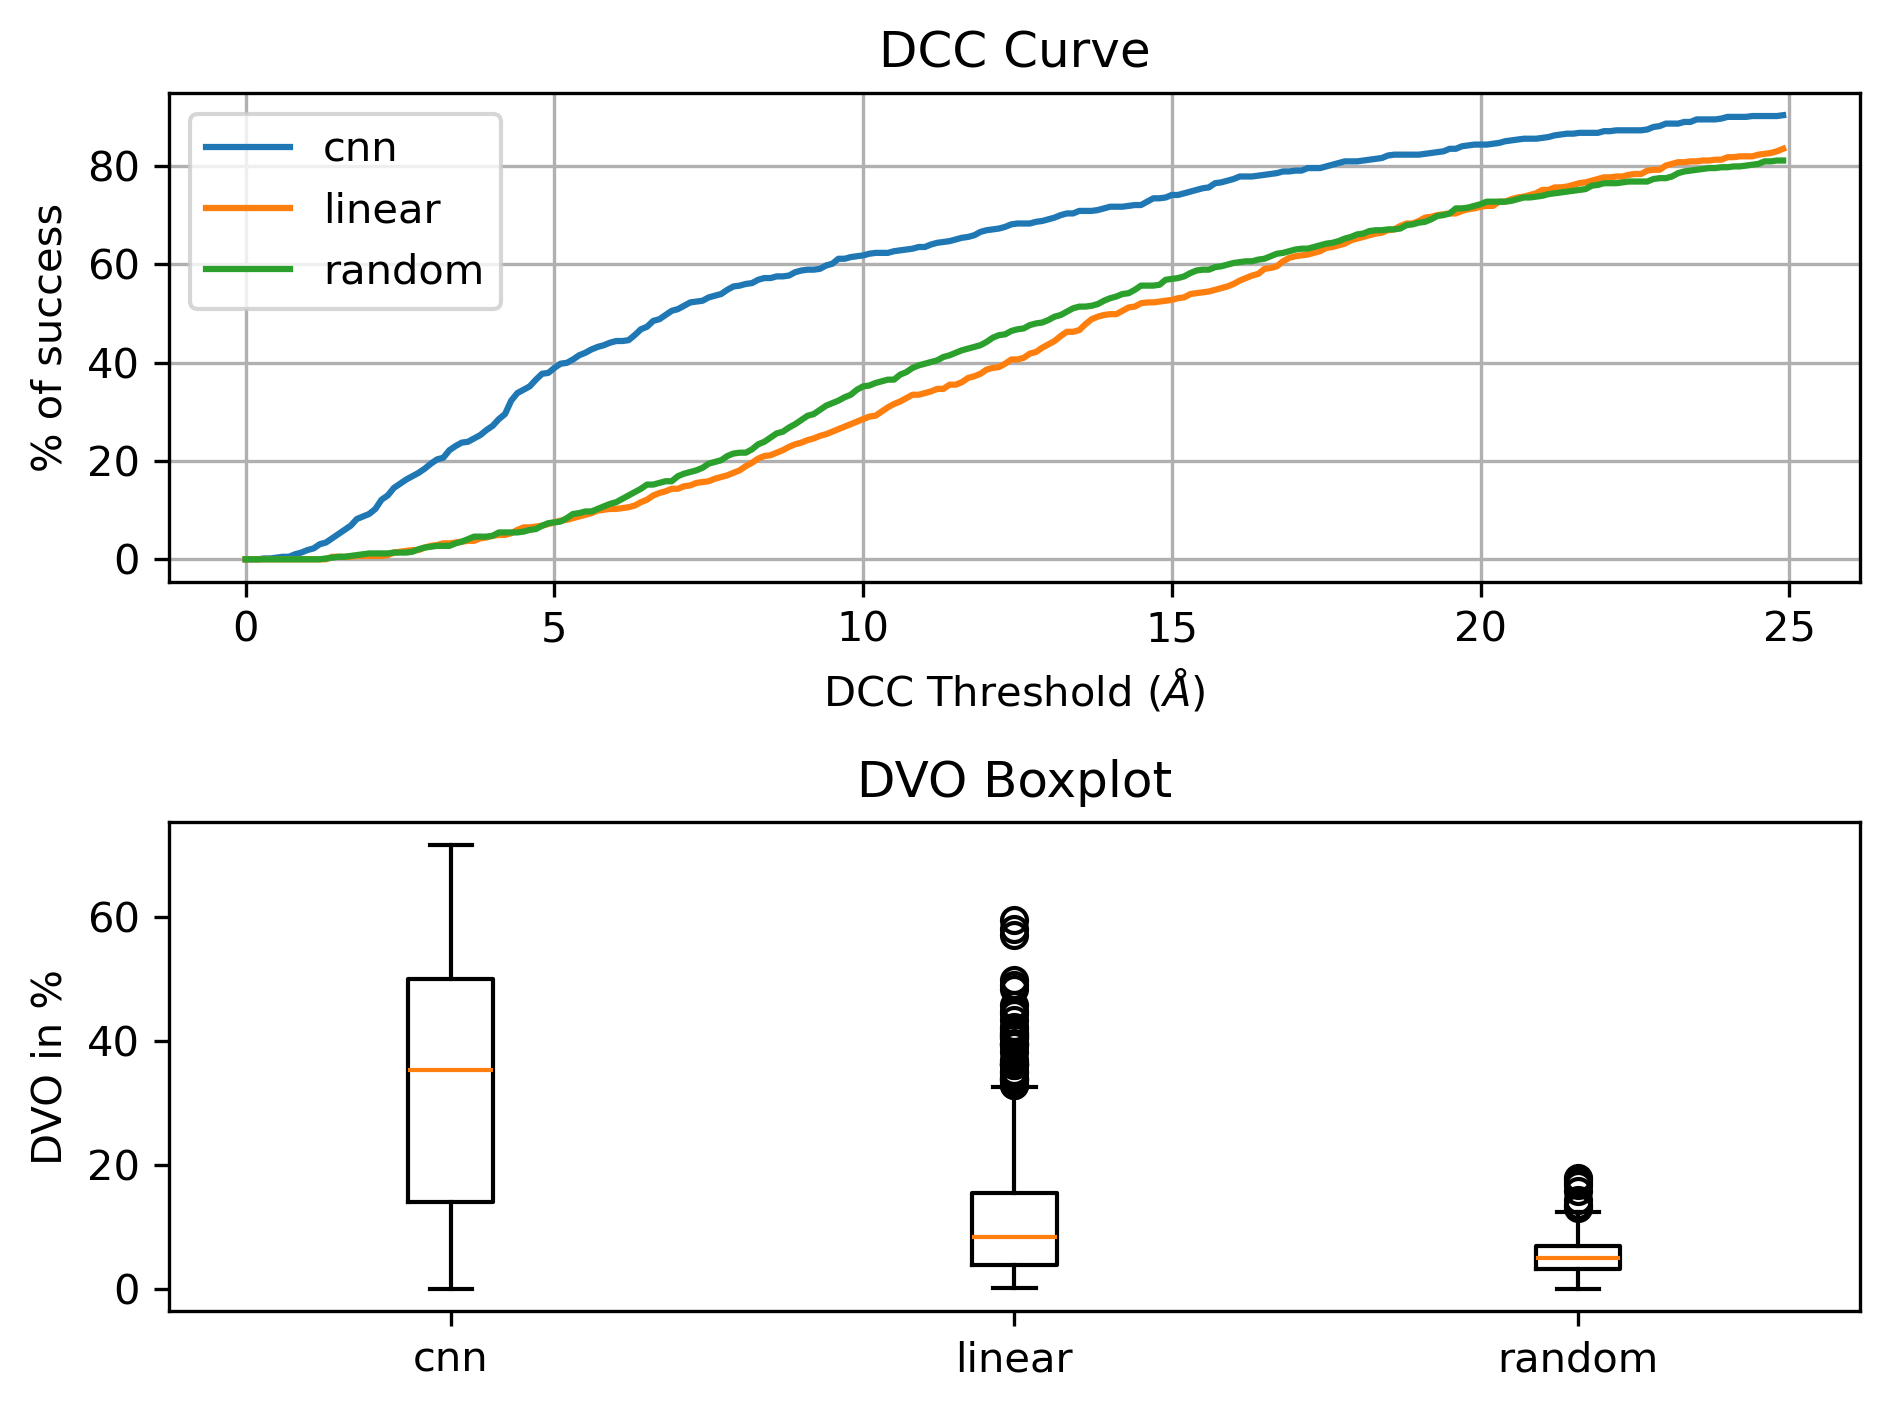

Theshold = 0.8


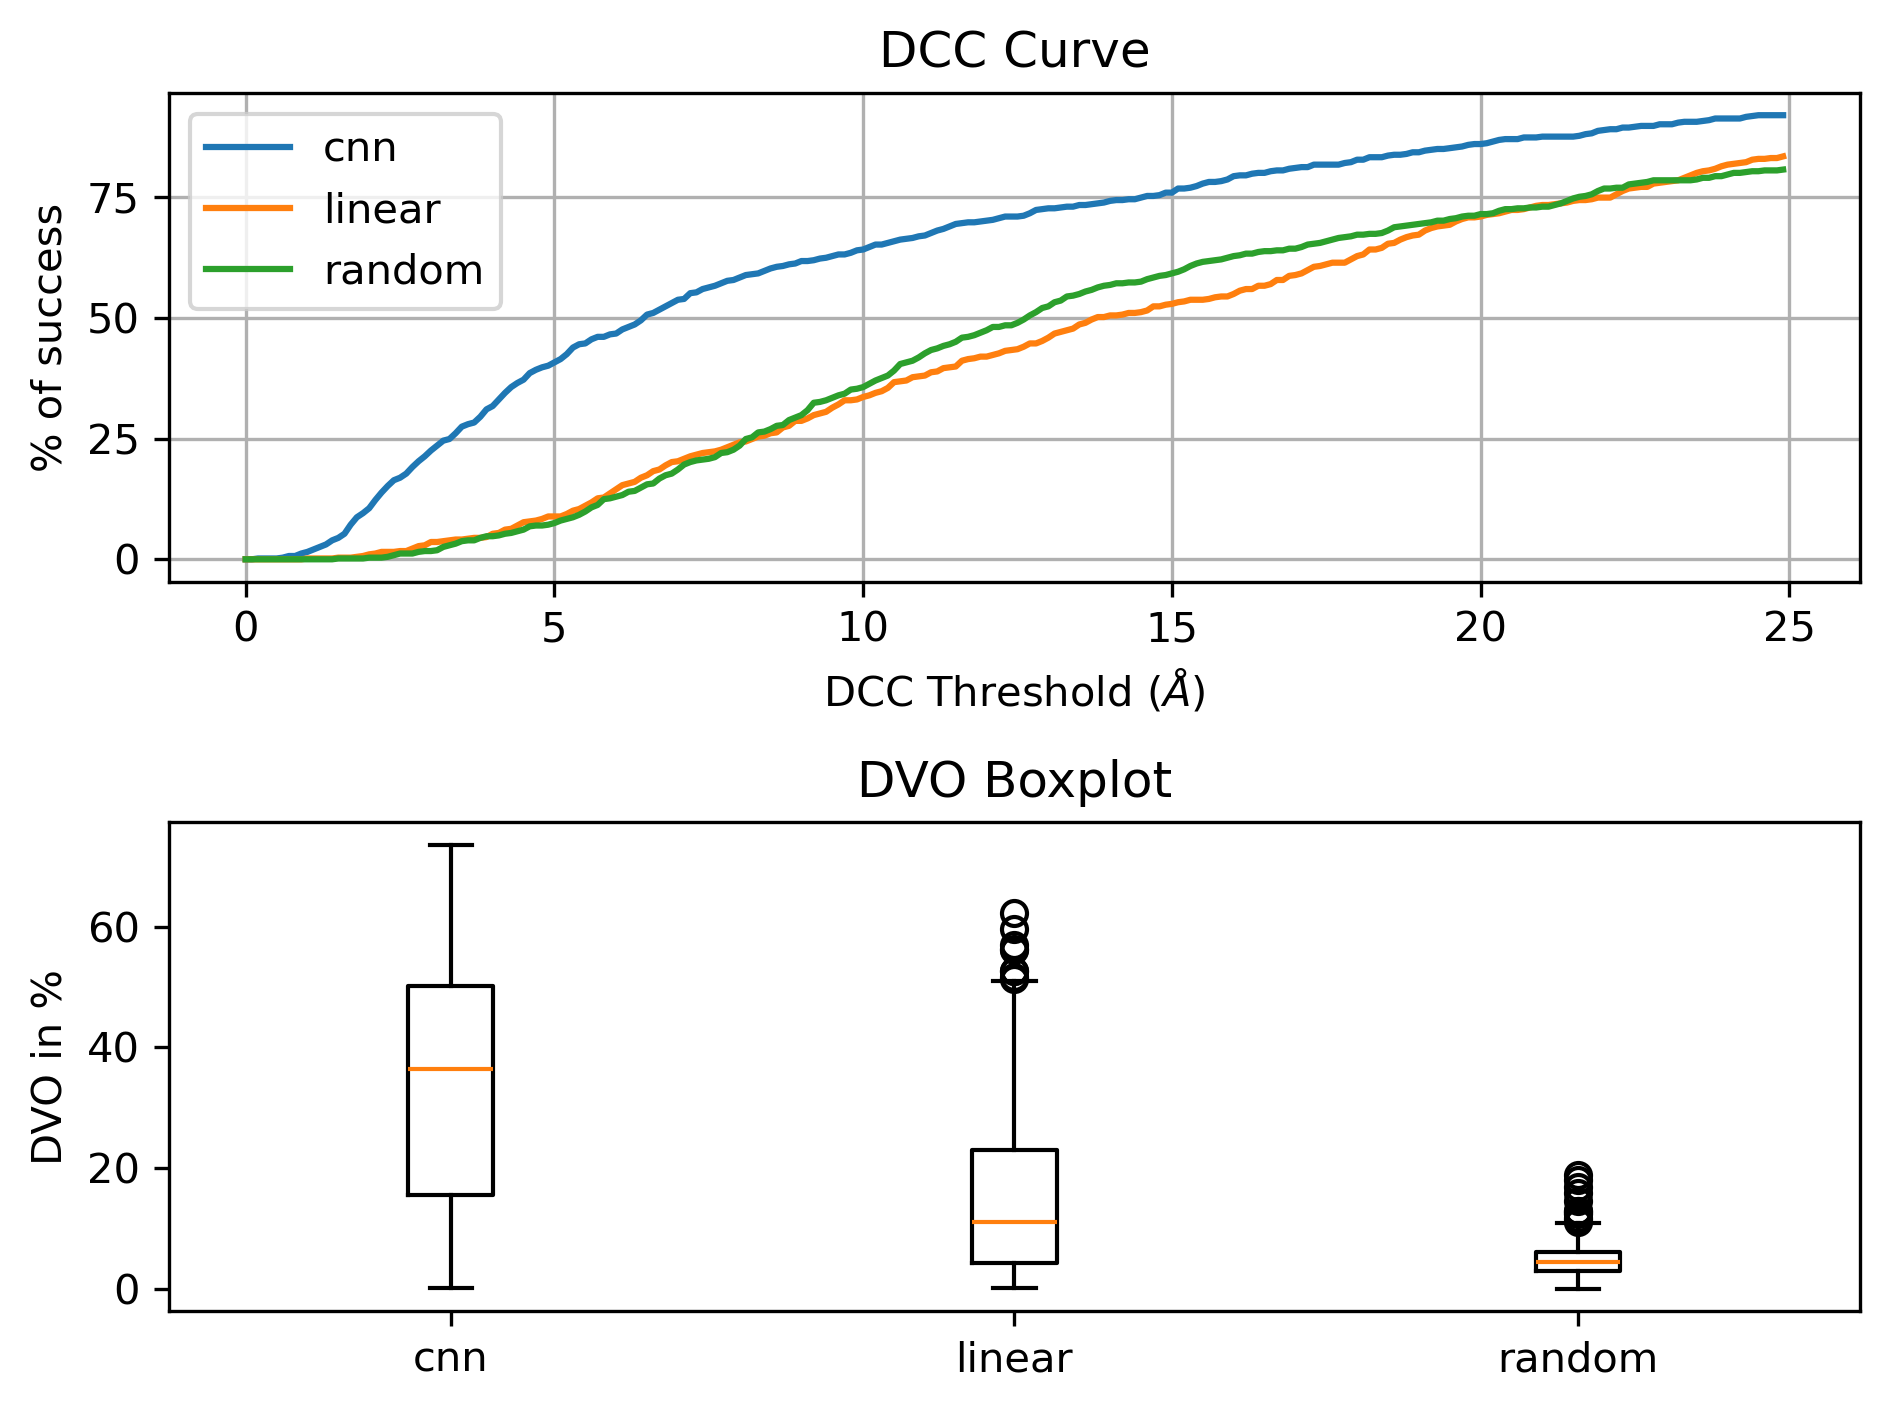

Theshold = 0.9


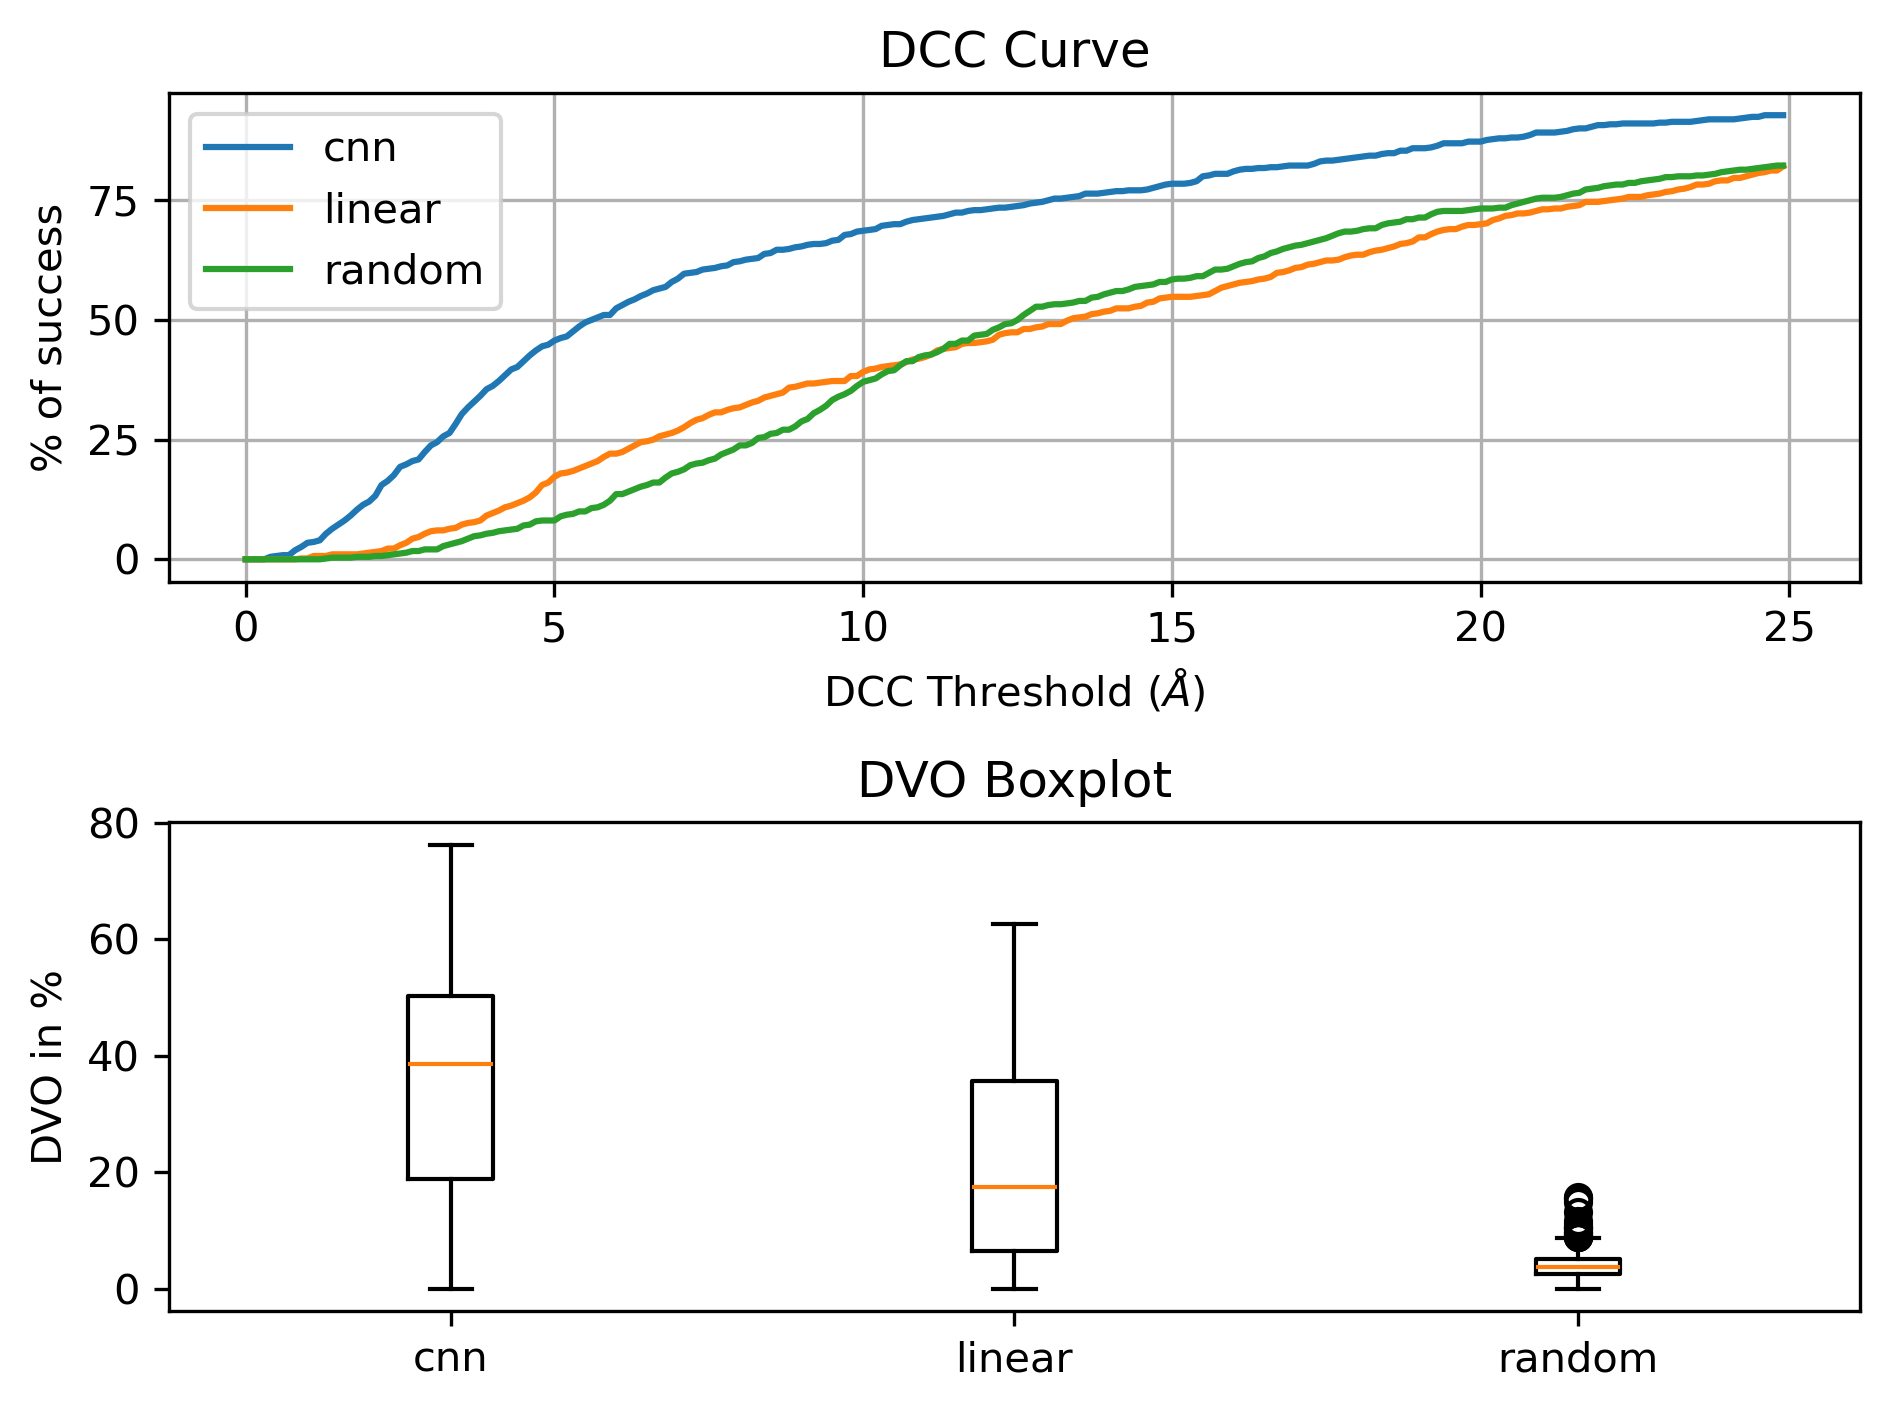

In [13]:
complete_metrics = []

for threshold in [0.5, 0.6, 0.7, 0.8, 0.9]:
    print(f'Theshold = {threshold}')

    df = analyse_metrics(FINAL_METRICS, threshold=threshold, save=f'Images/metrics_threshold_{threshold}.png')
    df.columns = [column + '_' + str(threshold) for column in df.columns]
    complete_metrics.append(df)

complete_metrics = pd.concat(complete_metrics, axis=1)

# Aggregated Metrics

As we can see, the threshold 0.9 performs the best, although tuning the threshold does not have a large influence of the output in general.

In [19]:
complete_metrics

,cnn_0.5,linear_0.5,random_0.5,cnn_0.6,linear_0.6,random_0.6,cnn_0.7,linear_0.7,random_0.7,cnn_0.8,linear_0.8,random_0.8,cnn_0.9,linear_0.9,random_0.9
Threshold,0.5,0.5,0.5,0.6,0.6,0.6,0.7,0.7,0.7,0.8,0.8,0.8,0.9,0.9,0.9
DCC Mean,11.154848,16.245989,17.983239,10.841299,16.233356,17.324113,10.522056,16.15194,16.983129,9.836749,15.85227,16.41558,9.171223,15.66766,16.224376
DCC SD,9.482213,9.207448,12.418907,9.294528,9.289628,12.184709,9.3559,9.451868,12.704678,8.903324,9.698132,12.032712,8.772727,11.280245,11.645572
DCC CI (95%),11.155 ± 0.0317,16.246 ± 0.0308,17.983 ± 0.0415,10.841 ± 0.0311,16.233 ± 0.0311,17.324 ± 0.0408,10.522 ± 0.0313,16.152 ± 0.0316,16.983 ± 0.0425,9.8367 ± 0.0298,15.852 ± 0.0324,16.416 ± 0.0402,9.1712 ± 0.0296,15.668 ± 0.0381,16.224 ± 0.0394
DCC 50%,8.0,14.4,14.3,7.8,14.3,14.1,6.9,14.2,13.3,6.5,13.8,12.7,5.6,13.4,12.5
DVO Mean,0.298297,0.061523,0.056983,0.309148,0.089155,0.056405,0.328502,0.116673,0.052871,0.339569,0.156245,0.047267,0.351069,0.213925,0.04013
DVO SD,0.207316,0.050858,0.034311,0.202162,0.08202,0.032534,0.202504,0.107776,0.029582,0.19676,0.141879,0.02622,0.190043,0.166586,0.022319
DVO CI (95%),0.2983 ± 0.000695,0.061523 ± 0.00017,0.056983 ± 0.000117,0.30915 ± 0.000677,0.089155 ± 0.000275,0.056405 ± 0.00011,0.3285 ± 0.000686,0.11667 ± 0.000364,0.052871 ± 0.000101,0.33957 ± 0.000665,0.15625 ± 0.000499,0.047267 ± 8.88e-05,0.35107 ± 0.000652,0.21393 ± 0.000615,0.04013 ± 7.62e-05


# Comparison

## Distribution shape

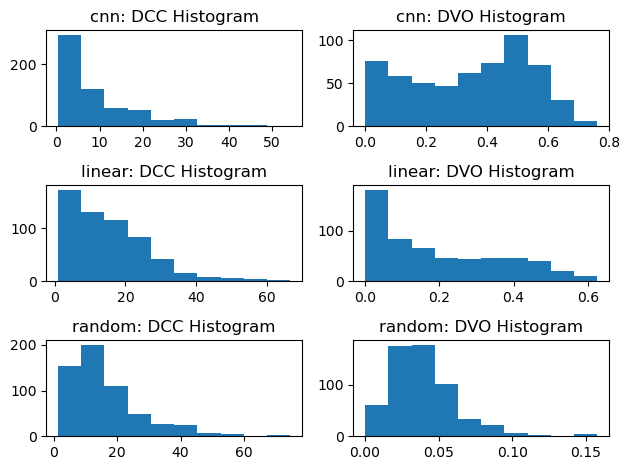

In [18]:
from matplotlib import pyplot as plt

metrics_df = pd.read_csv(FINAL_METRICS, sep='\t')
fig, axs = plt.subplots(3, 2)
for i, model in enumerate(metrics_df['Model'].unique()):
    
    axs[i][0].hist(metrics_df.loc[(metrics_df['Model'] == model) & (metrics_df.Threshold == 0.9), 'DCC'])
    axs[i][0].set_title(f'{model}: DCC Histogram')
    axs[i][1].hist(metrics_df.loc[(metrics_df['Model'] == model) & (metrics_df.Threshold == 0.9), 'DVO'])
    axs[i][1].set_title(f'{model}: DVO Histogram')

plt.tight_layout()
plt.show()

As we can see - the distributions are far from being normal. Thus, we have to use non-parametric test (Wilcoxon signed-rank test).

In [17]:
def wilcoxon_test(supposed_larger: Sequence,
                  supposed_smaller: Sequence,
                  supposed_larger_name: str,
                  supposed_smaller_name: str,
                  criterion_name: str,
                  better_if: str = 'larger') -> float:
    """
    Function to perform Wilcoxon signed rank-test between 2 distributions

    Args:
        supposed_larger (Sequence): sequence that is supposed to be larger
        supposed_smaller (Sequence): sequence that is supposed to be smaller
        supposed_larger_name (str): how to call the presumably larger variable
        supposed_smaller_name (str): how to call the presumably smaller variable
        criterion_name (str): name of the criterion
        better_if (str, optional): what result to consider as a better result ('smaller' or 'larger'). Defaults to 'larger'.

    Returns:
        float: p-value
    """

    # Check the input
    supposed_larger_name, supposed_smaller_name = str(supposed_larger_name), str(supposed_smaller_name)
    better_if, criterion_name = str(better_if).lower(), str(criterion_name)
    assert better_if in {'smaller', 'larger'}, f'better_if must be "smaller" or "larger", not {better_if}'

    # Perform the test
    test_value, p = wilcoxon(supposed_larger, supposed_smaller, alternative='greater')

    # Construct the report
    report = f'Accoring to Wilcoxon rank-test\n'
    
    if p < 0.05:
        report += f'\t{supposed_larger_name} has significantly larger by {criterion_name} than {supposed_smaller_name}\n'
        if better_if == 'larger':
            report += f'\twhich means that {supposed_larger_name} is significantly better in terms of {criterion_name}\n'
        else:
            report += f'\twhich means that {supposed_smaller_name} is significantly better in terms of {criterion_name}\n'
    else:
        report += f'\t{supposed_larger_name} is not significantly larger by {criterion_name} than {supposed_smaller_name}\n'

    report += f'\ttest value: {test_value:.5g}\n'
    report += f'\tp-value: {p:.5g}\n'

    print(report)
    return p

# Get Series
dcc_random = metrics_df.loc[(metrics_df.Model == 'random') & (metrics_df.Threshold == 0.9), 'DCC']
dcc_cnn = metrics_df.loc[(metrics_df.Model == 'cnn') & (metrics_df.Threshold == 0.9), 'DCC']
dcc_linear = metrics_df.loc[(metrics_df.Model == 'linear') & (metrics_df.Threshold == 0.9), 'DCC']

dvo_random = metrics_df.loc[(metrics_df.Model == 'random') & (metrics_df.Threshold == 0.9), 'DVO']
dvo_cnn = metrics_df.loc[(metrics_df.Model == 'cnn') & (metrics_df.Threshold == 0.9), 'DVO']
dvo_linear = metrics_df.loc[(metrics_df.Model == 'linear') & (metrics_df.Threshold == 0.9), 'DVO']

# Perform tests
wilcoxon_test(dcc_random, dcc_cnn, 'RANDOM MODEL', 'CNN_MODEL', 'DCC', better_if='smaller')
wilcoxon_test(dcc_random, dcc_linear, 'RANDOM MODEL', 'CNN_MODEL', 'DCC', better_if='smaller')
wilcoxon_test(dcc_linear, dcc_cnn, 'RANDOM MODEL', 'CNN_MODEL', 'DCC', better_if='smaller')

wilcoxon_test(dvo_cnn, dvo_random, 'RANDOM MODEL', 'CNN_MODEL', 'DVO', better_if='larger')
wilcoxon_test(dvo_linear, dvo_random, 'RANDOM MODEL', 'CNN_MODEL', 'DVO', better_if='larger')
wilcoxon_test(dvo_cnn, dvo_linear, 'RANDOM MODEL', 'CNN_MODEL', 'DVO', better_if='larger');



Accoring to Wilcoxon rank-test
	RANDOM MODEL has significantly larger by DCC than CNN_MODEL
	which means that CNN_MODEL is significantly better in terms of DCC
	test value: 1.5451e+05
	p-value: 3.9421e-68

Accoring to Wilcoxon rank-test
	RANDOM MODEL is not significantly larger by DCC than CNN_MODEL
	test value: 90683
	p-value: 0.055406

Accoring to Wilcoxon rank-test
	RANDOM MODEL has significantly larger by DCC than CNN_MODEL
	which means that CNN_MODEL is significantly better in terms of DCC
	test value: 1.4762e+05
	p-value: 7.9171e-56

Accoring to Wilcoxon rank-test
	RANDOM MODEL has significantly larger by DVO than CNN_MODEL
	which means that RANDOM MODEL is significantly better in terms of DVO
	test value: 1.6773e+05
	p-value: 2.8102e-95

Accoring to Wilcoxon rank-test
	RANDOM MODEL has significantly larger by DVO than CNN_MODEL
	which means that RANDOM MODEL is significantly better in terms of DVO
	test value: 1.564e+05
	p-value: 9.8398e-72

Accoring to Wilcoxon rank-test
	RANDO

# SCOPe families and Performance

Different SCOPe families: 174
SCOPe families with at least 5 examples: 27


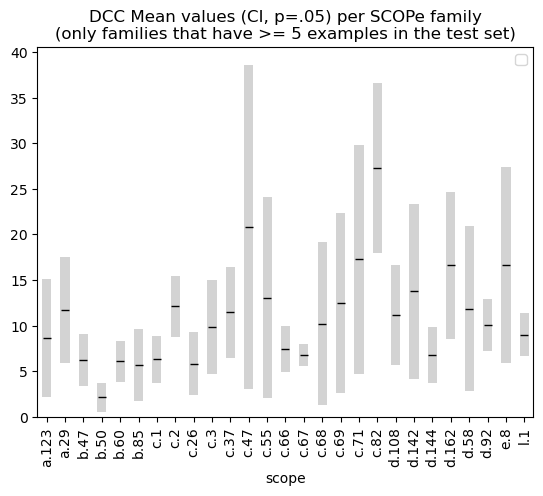

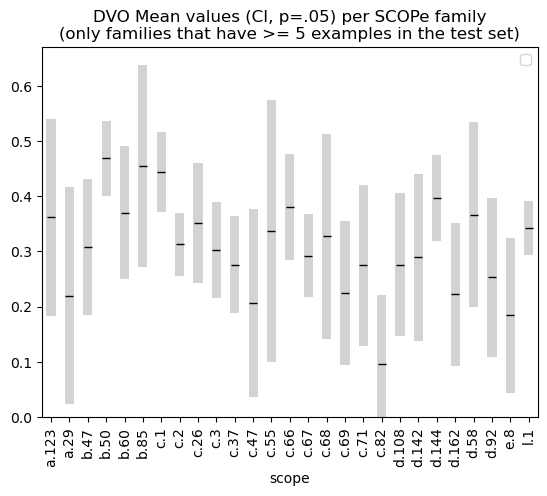

In [89]:
import numpy as np

def analyse_scope(metrics_path: str = 'Data/final_metrics.csv',
                  main_csv_path: str = 'Data/database.csv',
                  model_name: str = 'cnn',
                  threshold: float = 0.9,
                  save: str = None):
    """
    Plot and aggregate final metrics

    Args:
        metrics_path (str, optional): path to the final metrics CSV. Defaults to Data/final_metrics.csv.
        main_csv_path (str, optional): path to the main CSV. Defaults to Data/database.csv.
        model_name (str, optional): name of the chosen model. Defaults to 'cnn'ArithmeticError.
        threshold (float, optional): threshold to choose. Defaults to 0.5.
        save (str, optional): path to save the plot to. Defaults to None
    """

    assert isinstance(metrics_path, str), f'metrics_path must be str, not {type(metrics_path)}'
    assert isinstance(main_csv_path, str), f'main_csv_path must be str, not {type(main_csv_path)}'
    assert isinstance(model_name, str), f'model_name must be str, not {type(model_name)}'
    assert isinstance(threshold, float | int), f'threshold must be float (int), not {type(float)}'
    assert 0 <= threshold <= 1, f'threshold must be between 0 and 1, not {threshold}'
    assert isinstance(save, str | None), f'save must be str or None, not {type(save)}'

    # Load the database and extract SCOPe identifiers
    database = pd.read_csv(main_csv_path, sep='\t')[['scPDB ID', 'SCOPe Chain Classes']]
    database.rename(columns={'SCOPe Chain Classes': 'scope'}, inplace=True)
    database['scope'] = database['scope'].apply(lambda x: list(set('.'.join(xx.split(' ')[1].split('.')[:2]) for xx in x.split(' / '))) if isinstance(x, str) else [])

    # Unravel the database: make each scPDB - SCOPe a separate line
    unraveled = []
    for i, row in database.iterrows():
        for family in row['scope']:
            unraveled.append([row['scPDB ID'], family])
    unraveled = pd.DataFrame(unraveled, columns=['ID', 'scope'])

    # Load the metrics
    metrics_df = pd.read_csv(metrics_path, sep='\t')
    metrics_df = metrics_df.loc[(metrics_df['Threshold'] == threshold) & (metrics_df['Model'] == model_name)]
    metrics_df.rename(columns={'scPDB ID': 'ID'}, inplace=True)
    metrics_df.drop(columns=['Threshold', 'Model'], inplace=True)

    # Merge metrics with an unraveled database (inner mode)
    unraveled = pd.merge(unraveled, metrics_df, how='inner')
    unraveled.drop(columns=['ID'], inplace=True)
    print(f'Different SCOPe families: {len(unraveled['scope'].unique())}')

    # Get mean, std and count for metrics grouped by SCOPe IDs
    families = unraveled.groupby(by='scope', as_index=False).mean()
    families_std = unraveled.groupby(by='scope', as_index=False).std()
    families_std.rename(columns={'DCC': 'std DCC', 'DVO': 'std DVO'}, inplace=True)
    counts = unraveled[['scope', 'DCC']].groupby(by='scope', as_index=False).count()
    counts.rename(columns={'DCC': 'N'}, inplace=True)
    families = pd.merge(families, counts, how='left')
    families = pd.merge(families, families_std, how='left')

    # Compute confidence intervals of mean for DCC and DVO
    families['DCC CI'] = 1.96 * families['std DCC'] / np.sqrt(families['N'])
    families['DCC upper'] = families['DCC'] + families['DCC CI']
    families['DCC lower'] = families['DCC'] - families['DCC CI']
    families['DVO CI'] = 1.96 * families['std DVO'] / np.sqrt(families['N'])
    families['DVO upper'] = families['DVO'] + families['DVO CI']
    families['DVO lower'] = families['DVO'] - families['DVO CI']
    families.loc[families['DCC lower'] < 0, 'DCC lower'] = 0
    families.loc[families['DVO lower'] < 0, 'DVO lower'] = 0
    families = families.loc[families['N'] > 4]
    print(f'SCOPe families with at least 5 examples: {len(families)}')
    families.set_index('scope', inplace=True)

    # Plot DCC bars
    ax_dcc = families[['DCC upper']].plot.bar(color=['lightgrey'], label=None)
    ax_dcc = families[['DCC']].plot(color=['black'], ax=ax_dcc, label=None, style='_')
    ax_dcc = families[['DCC lower']].plot.bar(color=['white'], ax=ax_dcc, label=None)
    ax_dcc.set_title('DCC Mean values (CI, p=.05) per SCOPe family\n(only families that have >= 5 examples in the test set)')
    ax_dcc.legend([])

     # Save if required
    if save is not None:
        ax_dcc.get_figure().savefig(save.split('.')[0] + '_dcc.' + save.split('.')[1])

    # Plot DVO bars
    ax_dvo = families[['DVO upper']].plot.bar(color=['lightgrey'], label=None)
    ax_dvo = families[['DVO']].plot(color=['black'], ax=ax_dvo, label=None, style='_')
    ax_dvo = families[['DVO lower']].plot.bar(color=['white'], ax=ax_dvo, label=None)
    ax_dvo.set_title('DVO Mean values (CI, p=.05) per SCOPe family\n(only families that have >= 5 examples in the test set)')
    ax_dvo.legend([])

    # Save if required
    if save is not None:
        ax_dvo.get_figure().savefig(save.split('.')[0] + '_dvo.' + save.split('.')[1])

analyse_scope(FINAL_METRICS, MAIN_CSV, save='Images/scope_families.png')
